In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
from datetime import datetime, timedelta

LOG_FILE = "runs/cheddar-2.0/r1/train.log"
TARGET_TOKENS = 258_614_429/4

train_rows, val_rows = [], []

with open(LOG_FILE, "r") as f:
    for line in f:
        if not line.startswith("step"):
            continue

        step_match = re.search(r"step\s+(\d+)/(\d+)", line)
        if not step_match:
            continue

        step = int(step_match.group(1))
        max_steps = int(step_match.group(2))

        if "val_loss" in line:
            loss = re.search(r"val_loss\s+([\d.eE+-]+)", line)
            tokens = re.search(r"tokens\s+([\d.eE+-]+)B", line)

            if loss:
                val_rows.append({
                    "step": step,
                    "loss": float(loss.group(1)),
                    "tokens": float(tokens.group(1)) * 1e9 if tokens else np.nan,
                })
            continue

        patterns = {
            "epoch": r"epoch\s+([\d.eE+-]+)/",
            "shard": r"shard\s+(\d+)",
            "shard_progress": r"shard_progress\s+([\d.eE+-]+)%",
            "tokens": r"tokens\s+([\d.eE+-]+)B",
            "loss": r"loss\s+([\d.eE+-]+)",
            "lr": r"lr\s+([\d.eE+-]+)",
            "muon_lr": r"muon_lr\s+([\d.eE+-]+)",
            "norm": r"norm\s+([\d.eE+-]+)",
            "tok/sec": r"tok/sec\s+([\d.eE+-]+)",
            "dt": r"dt\s+([\d.eE+-]+)ms",
            "vram": r"vram\s+([\d.eE+-]+)GB",
        }

        row = {"step": step, "max_steps": max_steps}

        for key, pattern in patterns.items():
            match = re.search(pattern, line)
            if match:
                row[key] = float(match.group(1))

        if "tokens" in row:
            row["tokens"] *= 1e9

        if "dt" in row:
            row["dt"] /= 1000  # ms -> seconds

        train_rows.append(row)

train = pd.DataFrame(train_rows)
val = pd.DataFrame(val_rows)

if len(train):
    min_idx = train["loss"].idxmin()
    min_loss = train.loc[min_idx, "loss"]
    min_step = int(train.loc[min_idx, "step"])

    total_time = train["dt"].sum()
    avg_tok_sec = train["tok/sec"].mean()
    recent_tok_sec = train["tok/sec"].tail(500).mean()

    total_tokens = train["tokens"].iloc[-1]
    current_epoch = train["epoch"].iloc[-1]

    remaining_tokens = max(0, TARGET_TOKENS - total_tokens)
    remaining_sec = remaining_tokens / recent_tok_sec
    finish_time = datetime.now() + timedelta(seconds=remaining_sec)
    progress = min(100, total_tokens / TARGET_TOKENS * 100)

    print(f"Steps:             {len(train):,} / {int(train['max_steps'].iloc[-1]):,}")
    print(f"Epoch:             {current_epoch:.4f} / 1.0000")
    print(f"Tokens:            {total_tokens / 1e6:.2f}M")
    print(f"Total step time:   {total_time / 60:.2f} minutes")
    print(f"Average tok/sec:   {avg_tok_sec:,.0f}")
    print(f"Recent tok/sec:    {recent_tok_sec:,.0f}")
    print(f"Lowest train loss: {min_loss:.6f} at step {min_step:,}")
    print()

    if len(val):
        min_idx = val["loss"].idxmin()
        print(
            f"Lowest val loss:   {val.loc[min_idx, 'loss']:.6f} "
            f"at step {int(val.loc[min_idx, 'step']):,}"
        )
        print()

    print(
        f"Progress:          {progress:.2f}% "
        f"({total_tokens / 1e6:.2f}M / {TARGET_TOKENS / 1e6:.2f}M)"
    )
    print(f"Tokens Remaining:  {remaining_tokens / 1e6:.2f}M")
    print(f"Time Remaining:    {remaining_sec / 60:.1f} minutes")
    print(f"Estimated Finish:  {finish_time.strftime('%d %b %Y, %H:%M')}")

else:
    print("No training steps found in log.")

Steps:             494 / 494
Epoch:             0.2500 / 1.0000
Tokens:            64.70M
Total step time:   79.50 minutes
Average tok/sec:   13,582
Recent tok/sec:    13,582
Lowest train loss: 1.578149 at step 240

Lowest val loss:   1.735134 at step 494

Progress:          100.00% (64.70M / 64.65M)
Tokens Remaining:  0.00M
Time Remaining:    0.0 minutes
Estimated Finish:  07 Oct 2026, 19:35


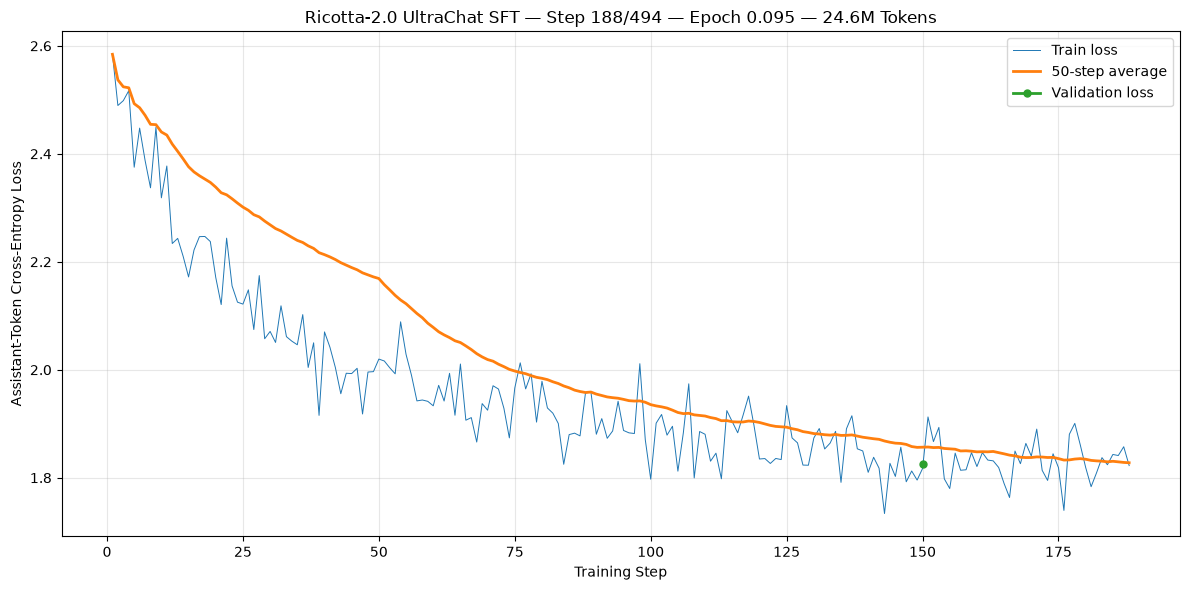

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    train["step"],
    train["loss"],
    linewidth=0.7,
    #alpha=0.35,
    label="Train loss",
)

for window in [50, 250]:
    if len(train) >= window:
        smooth = train["loss"].rolling(window, min_periods=1).mean()
        ax.plot(
            train["step"],
            smooth,
            linewidth=2,
            label=f"{window}-step average",
        )

if len(val):
    ax.plot(
        val["step"],
        val["loss"],
        marker="o",
        markersize=5,
        linewidth=2,
        label="Validation loss",
    )

current_step = int(train["step"].iloc[-1])
max_steps = int(train["max_steps"].iloc[-1])
current_epoch = train["epoch"].iloc[-1]
current_tokens = train["tokens"].iloc[-1]

ax.set_xlabel("Training Step")
ax.set_ylabel("Assistant-Token Cross-Entropy Loss")
ax.set_title(
    f"Ricotta-2.0 UltraChat SFT — "
    f"Step {current_step:,}/{max_steps:,} — "
    f"Epoch {current_epoch:.3f} — "
    f"{current_tokens / 1e6:.1f}M Tokens"
)

ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

KeyError: 'tok_sec'

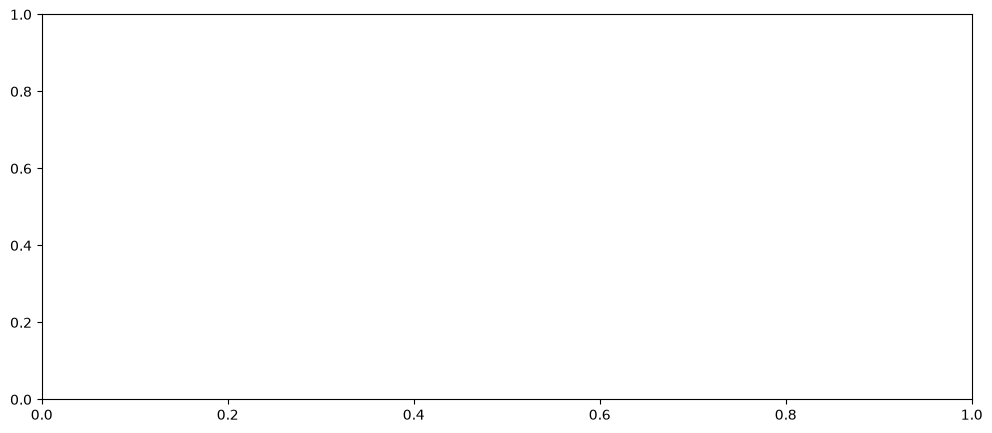

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    train["step"],
    train["tok_sec"],
    linewidth=0.7,
    alpha=0.8,
    label="Instantaneous",
)

smooth = train["tok_sec"].rolling(50, min_periods=1).mean()

ax.plot(
    train["step"],
    smooth,
    linewidth=2,
    label="50-step average",
)

ax.axhline(
    train["tok_sec"].mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"Mean: {train['tok_sec'].mean() / 1000:.1f}k tok/s",
)

ax.set_xlabel("Training Step")
ax.set_ylabel("Tokens / Second")
ax.set_title("Ricotta-2.0 Training Throughput")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

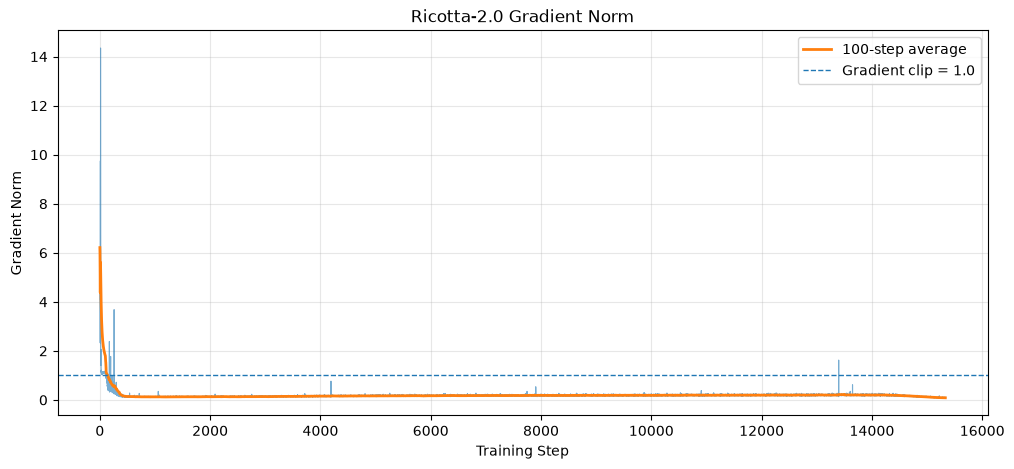

In [139]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    train["step"],
    train["norm"],
    linewidth=0.8,
    alpha=0.6,
)

smooth = train["norm"].rolling(100, min_periods=1).mean()

ax.plot(
    train["step"],
    smooth,
    linewidth=2,
    label="100-step average",
)

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
    label="Gradient clip = 1.0",
)

ax.set_xlabel("Training Step")
ax.set_ylabel("Gradient Norm")
ax.set_title("Ricotta-2.0 Gradient Norm")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

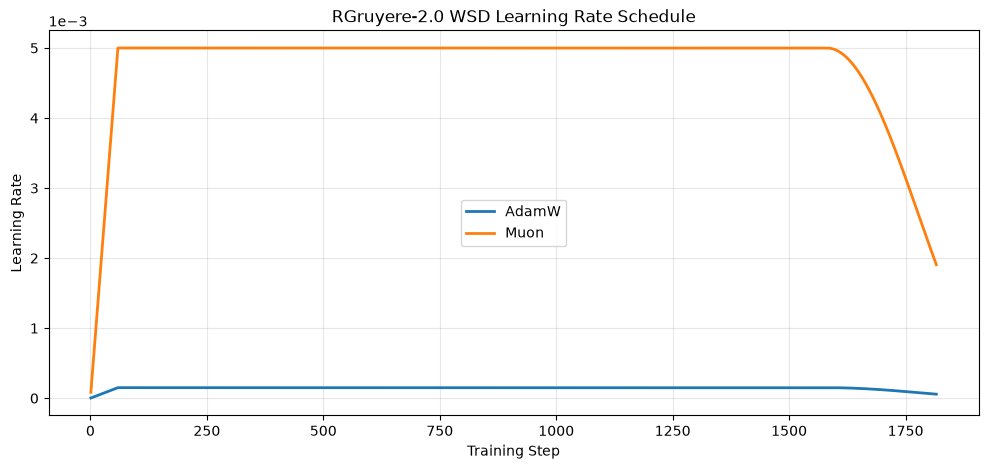

In [29]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    train["step"],
    train["lr"],
    linewidth=2,
    label="AdamW",
)

ax.plot(
    train["step"],
    train["muon_lr"],
    linewidth=2,
    label="Muon",
)

ax.set_xlabel("Training Step")
ax.set_ylabel("Learning Rate")
ax.set_title("RGruyere-2.0 WSD Learning Rate Schedule")
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

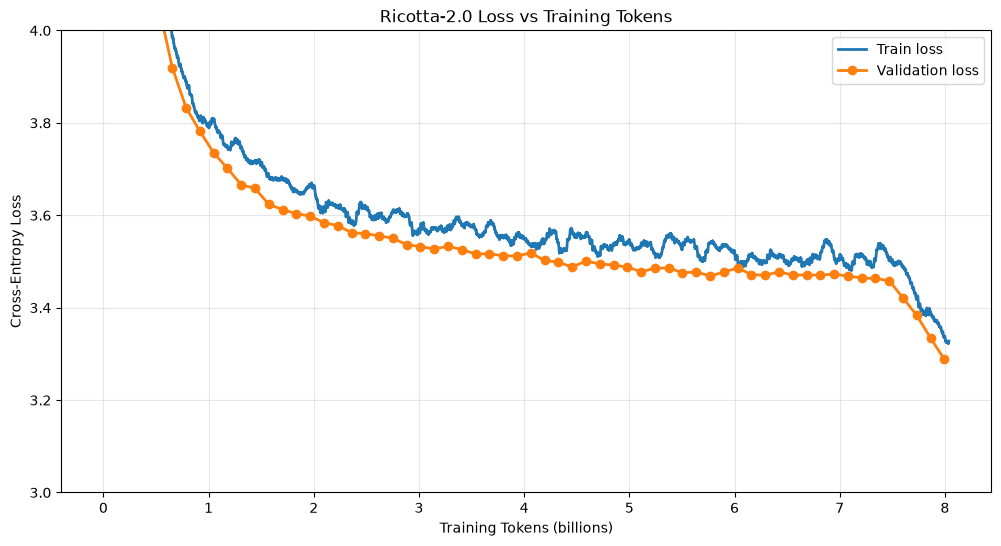

In [145]:
fig, ax = plt.subplots(figsize=(12, 6))

smooth = train["loss"].rolling(100, min_periods=1).mean()

ax.plot(
    train["tokens"] / 1e9,
    smooth,
    linewidth=2,
    label="Train loss",
)

if len(val):
    ax.plot(
        val["tokens"] / 1e9,
        val["loss"],
        marker="o",
        linewidth=2,
        label="Validation loss",
    )

ax.set_xlabel("Training Tokens (billions)")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Ricotta-2.0 Loss vs Training Tokens")
ax.set_ylim(top=4, bottom=3)
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

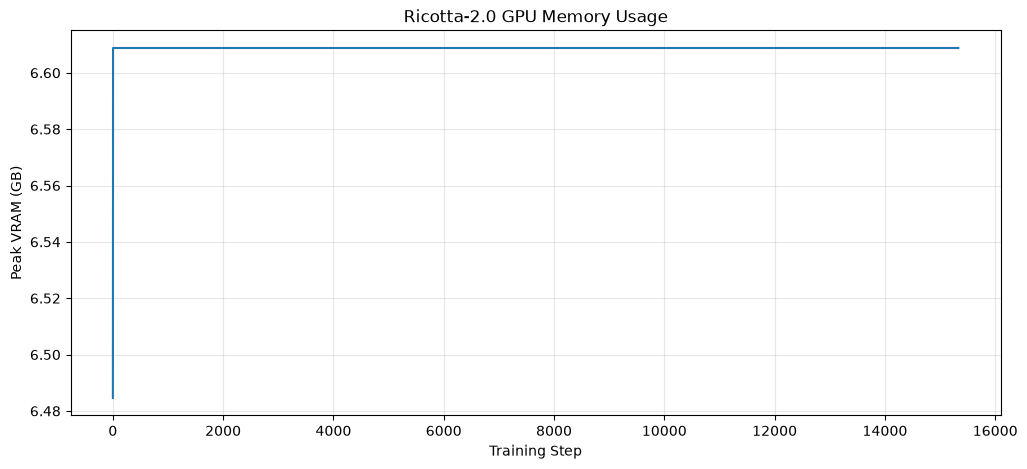

In [144]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    train["step"],
    train["vram_gb"],
    linewidth=1.5,
)

ax.set_xlabel("Training Step")
ax.set_ylabel("Peak VRAM (GB)")
ax.set_title("Ricotta-2.0 GPU Memory Usage")
ax.grid(True, alpha=0.3)
plt.show()